## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.
1. Start LMCache server first
```sh
/home/rani/vllm/.venv/bin/python -c 'from vllm.v1.core import kv_cache_utils; from lmcache.cli.main import main; main()' server \
    --l1-size-gb 8 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_kvcache_sdk_e2e \
    --no-l1-use-lazy
```
2. Wait until LMCache server is ready
```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```
3. Start vLLM once LMCache server is ready
```sh
env -u VLLM_PORT \
    CUDA_VISIBLE_DEVICES="7" \
    VLLM_ENABLE_V1_MULTIPROCESSING=0 \
    VLLM_BATCH_INVARIANT=1 \
    PYTHONHASHSEED=0 \
    vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.6 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_load_failure_policy":"recompute","kv_connector_extra_config":{"lmcache.mp.host":"tcp://localhost","lmcache.mp.port":6555,"lmcache.mp.mq_timeout":10}}' \
    --override-generation-config '{"temperature": 0}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```
4. Wait until vLLM is ready
```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

## Run E2E KV Edit Example

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch

# First Party
import lmcache.sdk.kvcache as lmc_sdk
import lmcache.sdk.stream as lmc_stream
import lmcache.sdk.batch as lmc_batch
from utils import rerotate_k_cache, make_post_completion

/home/rani/LMCache/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-06-29 23:29:49,141] LMCache INFO:  torch_dev=<module 'torch.cuda' from '/home/rani/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (__init__.py:62:lmcache)
[2026-06-29 23:29:49,407] LMCache INFO: Skipping backend lmcache.v1.platform.musa.ops: predicate returned False (__init__.py:102:lmcache)
[2026-06-29 23:29:49,408] LMCache INFO: Skipping backend lmcache.xpu_ops: predicate returned False (__init__.py:102:lmcache)
[2026-06-29 23:29:49,409] LMCache INFO: Using backend: lmcache.c_ops (__init__.py:120:lmcache)
[2026-06-29 23:29:49,475] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)


In [2]:
model_name = "Qwen/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
num_requests = 30
max_tokens = 5120
timeout = 60  # seconds
trust_remote_code = True
drop_factor = 0.5

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")

In [4]:
ds = load_dataset("raniayu/token-dropping-demo", split="train")


def build_prompt(ex) -> str:
    return (
        f"{ex['context']}\n\n"
        f"Answer this based on context with justifications!\n"
        f"Question: {ex['question']}\n"
        f"Answer: "
    )

In [5]:
post_completion = make_post_completion(vllm_url, model_name, timeout)

ctx = lmc_sdk.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

prompts = []

for i, example in enumerate(ds):
    if i >= num_requests:
        break
    prompt = tokenizer.encode(build_prompt(example))
    prompt = prompt[: (len(prompt) // chunk_size) * chunk_size]
    print(f"Prompt length: {len(prompt)} tokens")
    prompts.append(prompt)

[2026-06-29 23:29:55,251] LMCache INFO: Initialized LMCacheKVCacheContext with instance_id=759034, model_name=Qwen/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e (kvcache.py:104:lmcache.sdk.kvcache)
[2026-06-29 23:29:55,255] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:551:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-06-29 23:29:55,255] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-06-29 23:29:55,257] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e, pool_size=161061273600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-06-29 23:29:55,258] LMCache INFO: Worker non-GPU transfer context registered (instance_id=759034, mode=SHM) (worker_transfer.py:420:lmcache.v1.multiprocess.transfer_context.worker_transfer)


Prompt length: 9984 tokens
Prompt length: 9984 tokens
Prompt length: 10752 tokens
Prompt length: 10752 tokens
Prompt length: 10752 tokens
Prompt length: 11008 tokens
Prompt length: 11264 tokens
Prompt length: 12032 tokens
Prompt length: 12544 tokens
Prompt length: 12800 tokens
Prompt length: 12800 tokens
Prompt length: 13056 tokens
Prompt length: 13568 tokens
Prompt length: 13824 tokens
Prompt length: 14592 tokens
Prompt length: 14848 tokens
Prompt length: 15104 tokens
Prompt length: 15104 tokens
Prompt length: 15104 tokens
Prompt length: 15360 tokens
Prompt length: 15616 tokens
Prompt length: 15616 tokens
Prompt length: 15872 tokens
Prompt length: 15872 tokens
Prompt length: 15872 tokens
Prompt length: 15872 tokens
Prompt length: 16128 tokens
Prompt length: 16384 tokens
Prompt length: 16384 tokens
Prompt length: 16384 tokens


## With Token Dropping

In [6]:
batch = lmc_batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_stream.create_request(
        ctx=ctx,
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)

batch.prefill(sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True})


def drop_tokens_fn(kv_tensor, token_source):
    h = kv_tensor.shape[2]
    drop = int(h * drop_factor)
    keep_n = h - drop
    if keep_n < 2 * chunk_size:
        raise ValueError(
            f"drop {drop} too large for {h} tokens (need >= 2 chunks kept)"
        )
    print(f"compacting {h} tokens, dropping {drop}, keeping {keep_n}")

    lcs = h - chunk_size
    middle = random.sample(range(chunk_size, lcs), keep_n - 2 * chunk_size)
    keep_idx = torch.tensor(
        sorted(list(range(chunk_size)) + middle + list(range(lcs, h))),
        dtype=torch.long,
    )

    e_kv = rerotate_k_cache(
        kv_tensor[:, :, keep_idx, :].clone().to(work_device),
        old_positions=keep_idx.to(work_device),
        new_positions=torch.arange(
            keep_idx.numel(), device=work_device, dtype=torch.long
        ),
        model_config=config,
    )
    kept_ids = [token_source[i] for i in keep_idx.tolist()]
    return e_kv.cpu(), kept_ids


results = batch.modify(drop_tokens_fn)
results.emit()

compacting 10752 tokens, dropping 5376, keeping 5376
compacting 9984 tokens, dropping 4992, keeping 4992
compacting 9984 tokens, dropping 4992, keeping 4992
compacting 10752 tokens, dropping 5376, keeping 5376
compacting 11008 tokens, dropping 5504, keeping 5504
compacting 15872 tokens, dropping 7936, keeping 7936
compacting 16384 tokens, dropping 8192, keeping 8192
compacting 10752 tokens, dropping 5376, keeping 5376
compacting 12800 tokens, dropping 6400, keeping 6400
compacting 13056 tokens, dropping 6528, keeping 6528
compacting 16128 tokens, dropping 8064, keeping 8064
compacting 12544 tokens, dropping 6272, keeping 6272
compacting 15104 tokens, dropping 7552, keeping 7552
compacting 15616 tokens, dropping 7808, keeping 7808
compacting 12032 tokens, dropping 6016, keeping 6016
compacting 14848 tokens, dropping 7424, keeping 7424
compacting 15872 tokens, dropping 7936, keeping 7936
compacting 11264 tokens, dropping 5632, keeping 5632
compacting 15360 tokens, dropping 7680, keeping 

In [7]:
results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
after_drop_data = results.to_dict()

======================= Batched Stream Metrics ({mode}) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       559.02
Total Output Tokens:                                                      153600
Output Throughput (tokens/s):                                             274.76
---------------------------- Time per Token (TPOT) -----------------------------
Mean TPOT (ms):                                                            78.37
P50 TPOT (ms):                                                             53.99
P90 TPOT (ms):                                                             57.93
P99 TPOT (ms):                                                            485.26
----------------------------

In [8]:
lmc_sdk.close(ctx)

## Clear LMCache

Two options:

1. Run `!curl -X POST http://localhost:8080/clear-cache`
2. Restart LMCache and vLLM

In [9]:
ctx = lmc_sdk.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-06-29 23:43:42,130] LMCache INFO: Initialized LMCacheKVCacheContext with instance_id=759034, model_name=Qwen/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e (kvcache.py:104:lmcache.sdk.kvcache)
[2026-06-29 23:43:42,131] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:551:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-06-29 23:43:42,132] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:44:lmcache.v1.gpu_connector.kv_format.detection)
[2026-06-29 23:43:42,134] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_kvcache_sdk_e2e, pool_size=161061273600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-06-29 23:43:42,134] LMCache INFO: Worker non-GPU transfer context registered (instance_id=759034, mode=SHM) (worker_transfer.py:420:lmcache.v1.multiprocess.transfer_context.worker_transfer)


## Baseline (Without Token Dropping)

In [10]:
batch = lmc_batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_stream.create_request(
        ctx=ctx,
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
batch.prefill(sampling_params={"max_tokens": 1, "temperature": 1.0, "ignore_eos": True})
results = batch.decode(
    sampling_params={"max_tokens": max_tokens, "temperature": 1.0, "ignore_eos": True}
)
results.emit()
before_drop_data = results.to_dict()

======================= Batched Stream Metrics ({mode}) ========================
-------------------------------- Configuration ---------------------------------
Number of Streams:                                                            30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       918.00
Total Output Tokens:                                                      153600
Output Throughput (tokens/s):                                             167.32
---------------------------- Time per Token (TPOT) -----------------------------
Mean TPOT (ms):                                                            70.14
P50 TPOT (ms):                                                             55.62
P90 TPOT (ms):                                                             56.86
P99 TPOT (ms):                                                            156.92
----------------------------

## Result Plot

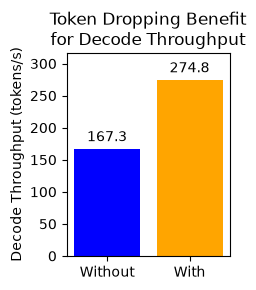

In [11]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [12]:
# Only close the context when done.
lmc_sdk.close(ctx)